In [82]:
import pandas as pd

ds = pd.read_csv('members.csv')

In [83]:
top_10_families = ds['family_code'].value_counts().nlargest(10).index
ds = ds[ds['family_code'].isin(top_10_families)]

In [84]:
dom_family_code = top_10_families[0]
dom_family = ds[ds['family_code'] == dom_family_code].iloc[0]
dom_family = dom_family.drop(['family_code'])
print(dom_family)

non_dom_family = ds[ds['family_code'] != dom_family_code]
non_dom_family = non_dom_family.drop(['family_code'], axis=1)
non_dom_family_agg = non_dom_family.mean()
print(non_dom_family_agg)

spawn_rate               0.0
death_rate          0.000134
replication_rate    0.044891
mutation_rate       0.037634
Name: 2, dtype: object
spawn_rate          0.000000
death_rate          0.000079
replication_rate    0.040218
mutation_rate       0.031584
dtype: float64


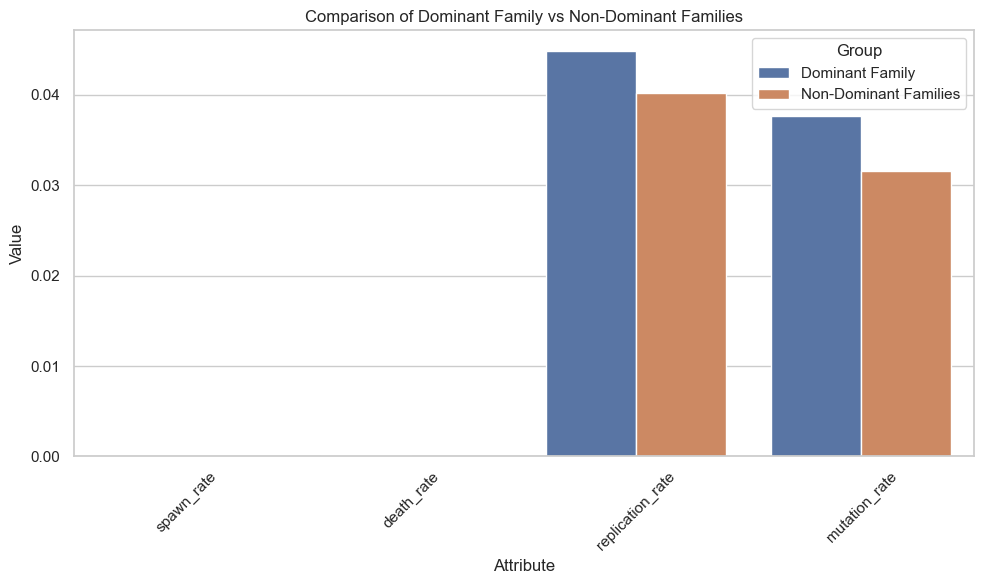

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
bar_data = pd.DataFrame({
    'Attribute': dom_family.index.tolist() * 2,
    'Value': dom_family.values.tolist() + non_dom_family_agg.values.tolist(),
    'Group': ['Dominant Family'] * len(dom_family) + ['Non-Dominant Families'] * len(non_dom_family_agg)
})
sns.barplot(data=bar_data, x='Attribute', y='Value', hue='Group', ax=ax)
plt.xticks(rotation=45)
plt.title('Comparison of Dominant Family vs Non-Dominant Families')
plt.tight_layout()
plt.show()